<a href="https://colab.research.google.com/github/sololeveling20/customer-segmentation-streamlit/blob/main/ML_Submission2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - **🛒 Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce**



##### **Project Type**    - EDA and Unsupervised Machine Learning
##### **Contribution**    - Individual
##### **Name -** Ramsha Shahid Shaikh


# **Project Summary -**

**This project analyzes e-commerce transaction data using exploratory data analysis and unsupervised machine learning techniques. Customers are segmented using RFM analysis and K-Means clustering to identify purchasing behavior patterns. An item-based collaborative filtering recommendation system is developed to suggest similar products. The project is implemented in Python and deployed using Streamlit for real-time interaction.**

# **GitHub Link -**

https://github.com/sololeveling20/customer-segmentation-streamlit


# **Problem Statement**


**The global e-commerce industry generates vast amounts of transaction data daily, offering valuable insights into customer purchasing behaviors. Analyzing this data is essential for identifying meaningful customer segments and recommending relevant products to enhance customer experience and drive business growth. This project aims to examine transaction data from an online retail business to uncover patterns in customer purchase behavior, segment customers based on Recency, Frequency, and Monetary (RFM) analysis, and develop a product recommendation system using collaborative filtering techniques.**

**Real-time Business Use Cases:**

**-Customer Segmentation for Targeted Marketing Campaigns.**

**-Personalized Product Recommendations on E-Commerce Platforms**

**-Identifying At-Risk Customers for Retention Programs**

**-Dynamic Pricing Strategies Based on Purchase Behavior**

**-Inventory Management and Stock Optimization Based on Customer Demand Patterns**



# ***Let's Begin !***

## ***1. Know Your Data***

### **Import Libraries**

In [ ]:
# Step 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### **Dataset Loading**

In [ ]:
# Load Dataset
# Step 2 - Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
retail_df = pd.read_csv('/content/drive/MyDrive/ML_Submission-2/online_retail.csv')

### **Dataset First View**

In [5]:
# Dataset First Look
retail_df.head(100)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
95,536378,22352,LUNCH BOX WITH CUTLERY RETROSPOT,6,2022-12-01 09:37:00,2.55,14688.0,United Kingdom
96,536378,21212,PACK OF 72 RETROSPOT CAKE CASES,120,2022-12-01 09:37:00,0.42,14688.0,United Kingdom
97,536378,21975,PACK OF 60 DINOSAUR CAKE CASES,24,2022-12-01 09:37:00,0.55,14688.0,United Kingdom
98,536378,21977,PACK OF 60 PINK PAISLEY CAKE CASES,24,2022-12-01 09:37:00,0.55,14688.0,United Kingdom


### **Dataset Rows & Columns count**

In [6]:
# Dataset Rows & Columns count
retail_df.shape

(541909, 8)

**We know are dataset have 541909 rows and 8 columns**

### **Dataset Information**

In [7]:
# Dataset Info
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


**Buisness Insight -**

**1) Nature of Business Data -** The dataset contains over 540,000 transactional records, indicating a high-volume retail / e-commerce business. Each record corresponds to a product-level transaction, suggesting that a single customer purchase (invoice) may consist of multiple products.

**Business Insight:** The company operates at large scale, handling thousands of product transactions daily, requiring robust inventory and billing systems.

**2) Invoice-Based Sales Model -** The presence of an InvoiceNo column with complete data indicates that sales are recorded through a formal invoicing system, where multiple items can be associated with a single purchase.

**Business Insight:** Sales can be analyzed at both item level and purchase (invoice) level, enabling insights into average order size and customer buying patterns.

**3) Product-Centric Operations -** Columns such as StockCode and Description show that each transaction is linked to a specific product.

**Business Insight:** The dataset allows detailed product performance analysis, such as identifying top-selling items and managing inventory based on demand.

**4) Presence of Product Returns -** The Quantity column is stored as an integer and typically includes negative values in retail datasets, which represent returned items.

**Business Insight:** The business tracks returns and cancellations, allowing analysis of product return rates and customer satisfaction issues.

**5) Time-Based Sales Tracking -** The InvoiceDate column records the date and time of each transaction, indicating that sales occur continuously over time.

**Business Insight:** The business can perform time-based analysis such as daily, monthly, or seasonal sales trends to support demand forecasting.

**6) Pricing Strategy Visibility -** The UnitPrice column captures the price per unit for each product, enabling revenue calculations when combined with quantity.

**Business Insight:** The company can analyze pricing effectiveness, discounts, and revenue contribution at the product level.

**7) Partial Customer Identification -** Only about 75% of transactions contain a CustomerID, while the rest are missing.

**Business Insight:** A significant portion of sales comes from guest or unidentified customers, indicating opportunities to improve customer registration and loyalty programs.

**8) International Market Presence -** The Country column is fully populated, suggesting that the business serves customers across multiple countries.

**Business Insight:** The company operates in international markets, allowing geographical sales analysis and region-specific business strategies.

**9) Data Quality Observations -** Missing values in Description and CustomerID indicate real-world data imperfections.

**Business Insight:** Data cleaning and preprocessing are necessary before advanced analytics, highlighting the importance of data governance and quality control.

#### Duplicate Values

In [8]:
retail_df.duplicated()


,0
0,False
1,False
2,False
3,False
4,False
...,...
541904,False
541905,False
541906,False
541907,False


In [9]:
retail_df[retail_df.duplicated()]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2022-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2022-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2022-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2022-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2022-12-01 11:49:00,2.95,17920.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2023-12-09 11:34:00,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2023-12-09 11:34:00,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2023-12-09 11:34:00,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,2023-12-09 11:34:00,2.10,14446.0,United Kingdom


In [10]:
# Dataset Duplicate Value Count
len(retail_df[retail_df.duplicated()])

5268

In [11]:
retail_df.duplicated().sum()

np.int64(5268)

#### Missing Values/Null Values

In [12]:
# Total missing per column
retail_df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [13]:
# Total no.of missing values in complete dataset
retail_df.isnull().sum().sum()

np.int64(136534)

**Business Insight:** The dataset shows high overall completeness, with missing values primarily concentrated in customer identification and a small portion of product descriptions, reflecting real-world retail data conditions.

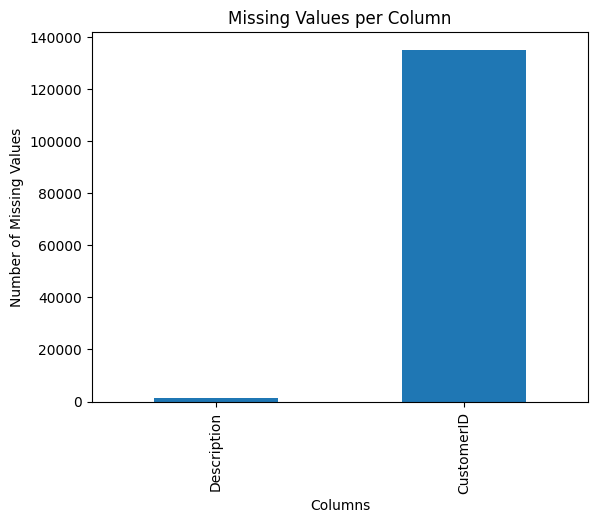

In [14]:
# Visualizing the missing values
import matplotlib.pyplot as plt

missing = retail_df.isnull().sum()

missing[missing > 0].plot(kind='bar')
plt.title("Missing Values per Column")
plt.ylabel("Number of Missing Values")
plt.xlabel("Columns")
plt.show()


**Insight:** Missing values are concentrated mainly in CustomerID, while other columns are largely complete.

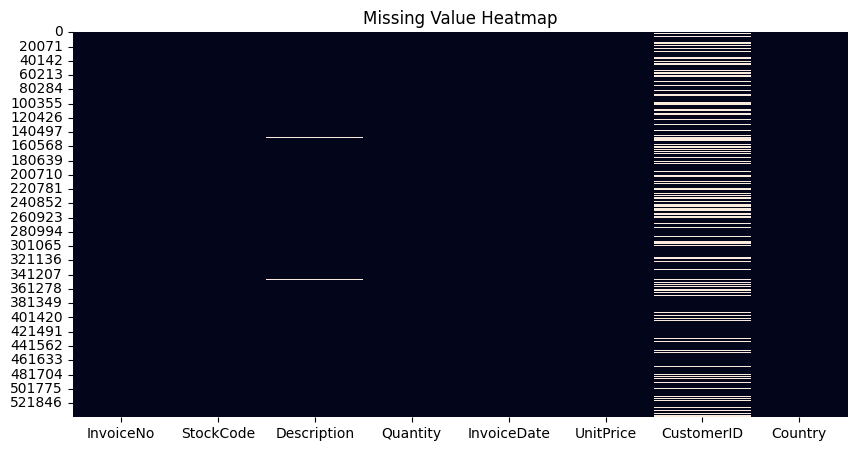

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.heatmap(retail_df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()


**Insight:** Missing values are not randomly distributed across all columns but are primarily concentrated in specific fields.

In [16]:
missing_percent = (retail_df.isnull().sum() / len(retail_df)) * 100
missing_percent[missing_percent > 0]


,0
Description,0.268311
CustomerID,24.926694


**Insight:** CustomerID has a significantly higher missing percentage compared to other columns, which may affect customer-level analysis.

### What did you know about your dataset?

**Answer Here:**

The dataset is a large-scale online retail transaction dataset consisting of 541,909 records and 8 columns, where each row represents a product-level transaction associated with a customer invoice.

It contains detailed information about invoices, products, quantities sold, unit prices, transaction timestamps, customer identifiers, and country of purchase. This structure enables analysis at both the item level and the invoice (order) level, allowing insights into customer purchasing behavior and order composition.

Most of the dataset columns are complete, indicating reliable recording of transactional, pricing, temporal, and geographical data. However, missing values are primarily concentrated in the CustomerID column, with a smaller proportion missing in product descriptions. This reflects real-world retail scenarios such as guest checkouts or incomplete product metadata.

Overall, the dataset supports sales analysis, product performance evaluation, time-based trend analysis, and geographical insights. While customer-level analysis is partially constrained due to missing customer identifiers, the available data remains sufficient for meaningful segmentation, behavioral analysis, and recommendation system development.

## ***2. Understanding Your Variables***

In [17]:
# Dataset Columns
retail_df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [18]:
# Dataset Describe
retail_df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [19]:
retail_df['Quantity'].describe()


,Quantity
count,541909.000000
mean,9.552250
std,218.081158
min,-80995.000000
25%,1.000000
50%,3.000000
75%,10.000000
max,80995.000000


In [20]:
retail_df['UnitPrice'].describe()


,UnitPrice
count,541909.000000
mean,4.611114
std,96.759853
min,-11062.060000
25%,1.250000
50%,2.080000
75%,4.130000
max,38970.000000


### Variables Description

**Answer Here:**

**Observations for Quantity-**

Most values ≈ 3

Some values are extremely large

Some values are extremely negative

Std = 218

**Business Insight -**

Most transactions involve a small number of items, but a few transactions involve very large quantities or returns, which causes high variation in the data. Lager std also shows data is not uniform but rather highly spread.

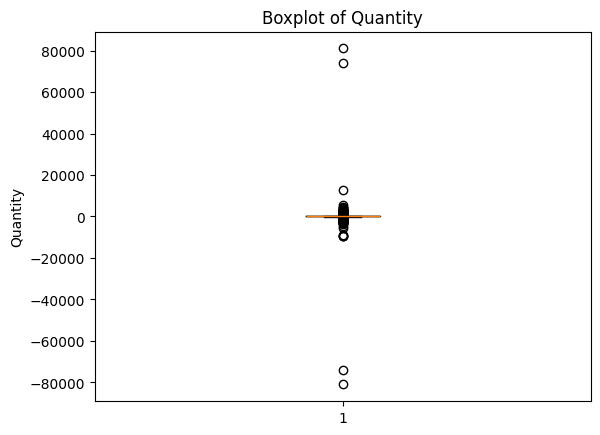

In [21]:
import matplotlib.pyplot as plt

plt.boxplot(retail_df['Quantity'])
plt.title("Boxplot of Quantity")
plt.ylabel("Quantity")
plt.show()


**Observations -** We can see the range is very small and end points are to far.

**Lets Zoom in because we can't understand the range**

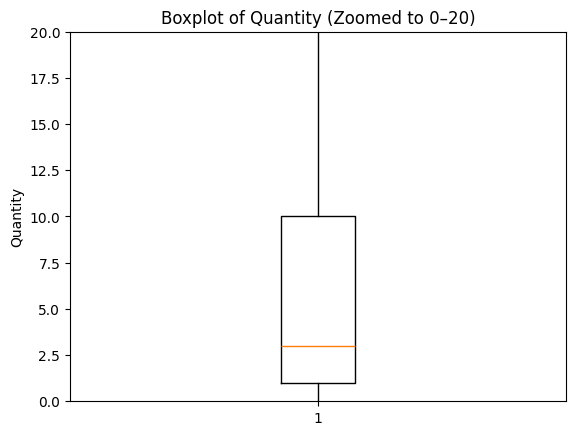

In [22]:
# Zoom It
import matplotlib.pyplot as plt

plt.boxplot(retail_df['Quantity'])
plt.ylim(0, 20)   # zoom to range 0–20
plt.title("Boxplot of Quantity (Zoomed to 0–20)")
plt.ylabel("Quantity")
plt.show()


**Business Insight -**

The boxplot shows that the majority of transactions involve small quantities, with the middle 50% of values concentrated in a narrow range. However, several extreme positive and negative outliers are present, indicating rare bulk purchases and product returns. These outliers create high variability in the data and significantly affect average-based measures.

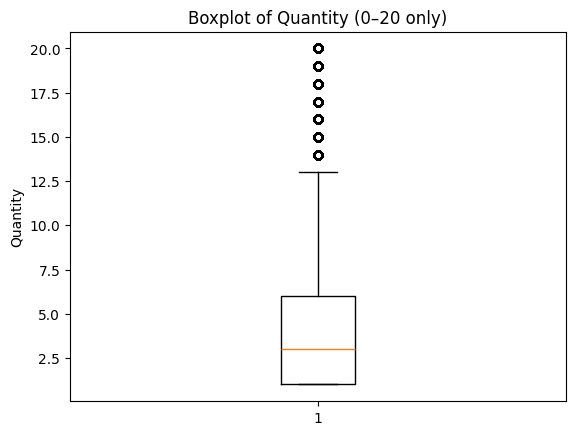

In [23]:
# Optional for normal behaviour
zoom_df = retail_df[retail_df['Quantity'].between(0, 20)]

plt.boxplot(zoom_df['Quantity'])
plt.title("Boxplot of Quantity (0–20 only)")
plt.ylabel("Quantity")
plt.show()


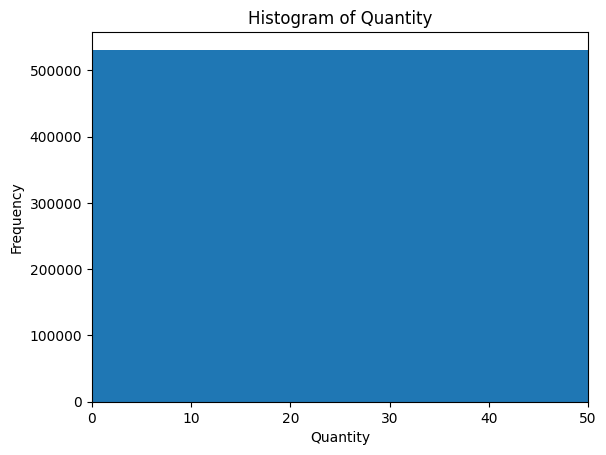

In [24]:
import matplotlib.pyplot as plt

plt.hist(retail_df['Quantity'], bins=50)
plt.xlim(0, 50)   # zoom to normal range
plt.title("Histogram of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

**Observations:**

Matplotlib stacks huge frequencies into very narrow bins → everything overlaps → looks like one giant block.

We can't conclude anything yet.

In [25]:
retail_df['Quantity'].skew()

np.float64(-0.2640763070668848)

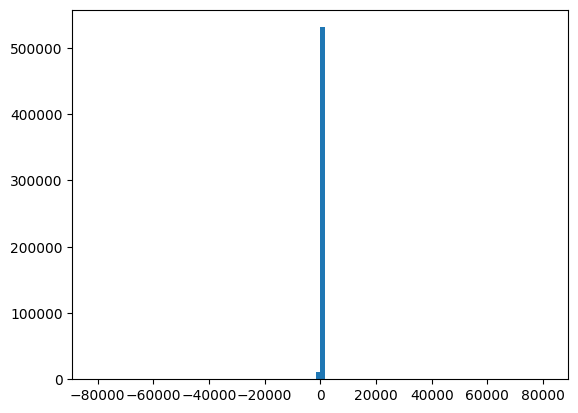

In [26]:
import matplotlib.pyplot as plt
plt.hist(retail_df['Quantity'], bins=100)
plt.show()


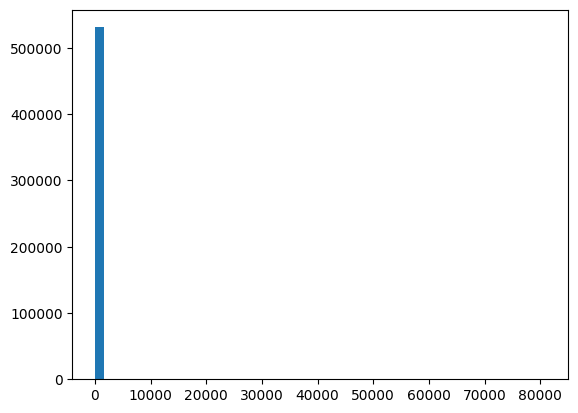

In [27]:
import matplotlib.pyplot as plt
plt.hist(retail_df[retail_df['Quantity'] > 0]['Quantity'], bins=50)
plt.show()


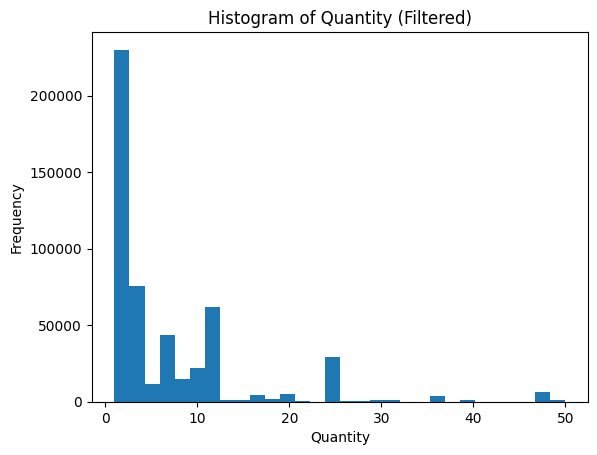

In [28]:
# Take only quantity column
q = retail_df['Quantity']
# Keep only normal-sized purchases (1 to 50 items)
# Remove: Returns (negative)
# Rare bulk purchases (very large)
q = q[(q > 0) & (q <= 50)]

plt.hist(q, bins=30)
plt.title("Histogram of Quantity (Filtered)")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()


**Observations :**

The Quantity variable represents the number of items involved in each transaction and shows high variability across the dataset.

Most transactions involve small quantities, with the median value around 3, indicating that customers typically purchase only a few items per transaction.

About 75% of transactions involve 10 items or fewer, confirming that normal purchasing behavior is concentrated at low quantity values.

The dataset contains extreme positive and negative quantity values, which represent bulk purchases and product returns, respectively.

These extreme values significantly increase the range and standard deviation, making the average quantity higher than what is typical for most transactions.

Due to the presence of returns and extreme bulk orders, the Quantity distribution shows slight skewness and is not normally distributed.

After filtering out returns and extreme values for visualization, the underlying distribution of normal purchase quantities appears right-skewed, with higher frequency at lower quantities.

In [29]:
# New Column with purchase quantity
sales_df = retail_df[retail_df['Quantity'] > 0]
sales_df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2022-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2022-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2022-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2022-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2022-12-01 08:34:00,1.69,13047.0,United Kingdom


**Observation:**

After removing returned items, the dataset shows that most customers purchase small quantities of multiple products per invoice, with occasional bulk orders, indicating a predominantly retail-focused business with strong cross-selling potential.

In [30]:
# New column with return quantity
returns_df = retail_df[retail_df['Quantity'] < 0]
returns_df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2022-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2022-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2022-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2022-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2022-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2022-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2022-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2022-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2022-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2022-12-01 12:38:00,4.25,17897.0,United Kingdom


**Observation -**

Returned transactions are clearly identifiable through negative quantities and cancellation invoice numbers, often involving bulk items processed in batches, indicating systematic return handling and highlighting the importance of excluding these records from sales-based analysis.

**UnitPrice**

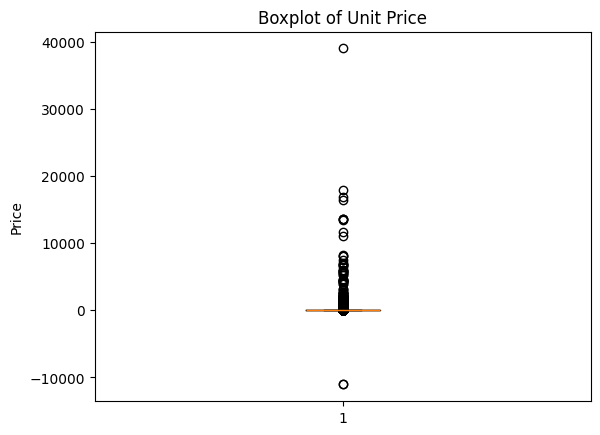

In [31]:
import matplotlib.pyplot as plt

plt.boxplot(retail_df['UnitPrice'])
plt.title("Boxplot of Unit Price")
plt.ylabel("Price")
plt.show()


**Observation -**

The boxplot of UnitPrice shows that most products are priced at low values, with the median price lying close to zero. However, the presence of several extreme positive outliers indicates a small number of high-priced items or special transactions. Additionally, negative unit prices are observed, suggesting refunds, pricing adjustments, or data inconsistencies. Overall, the distribution of unit prices is highly skewed with significant variability, highlighting the need for data cleaning and outlier handling before further analysis.

**Lets Zoom it because we can't understand the range**

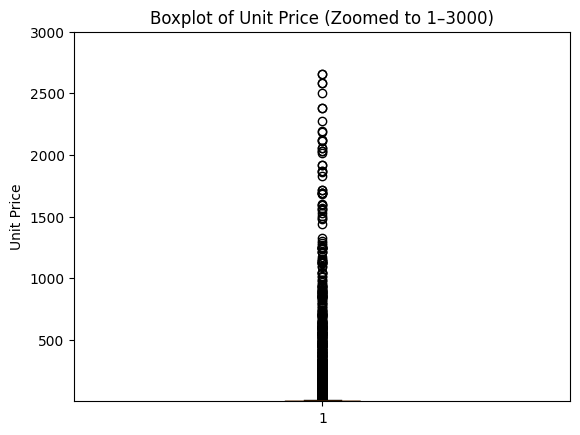

In [32]:
# Zoom it for UnitPrice
import matplotlib.pyplot as plt

plt.boxplot(retail_df['UnitPrice'])
plt.ylim(1,3000)   # zoom to normal price range
plt.title("Boxplot of Unit Price (Zoomed to 1–3000)")
plt.ylabel("Unit Price")
plt.show()


**Observations -**

Most product prices are very low and tightly grouped near the bottom of the chart.

The median price is close to zero, showing that typical items are inexpensive.

Even after zooming, there are many points above the box, meaning outliers still exist.

These outliers represent less common, higher-priced items.

The price data is not evenly spread; it is skewed, with most values small and a few much larger.

This confirms that extreme prices are frequent enough to affect analysis, so price data should be cleaned or capped before deeper analysis.

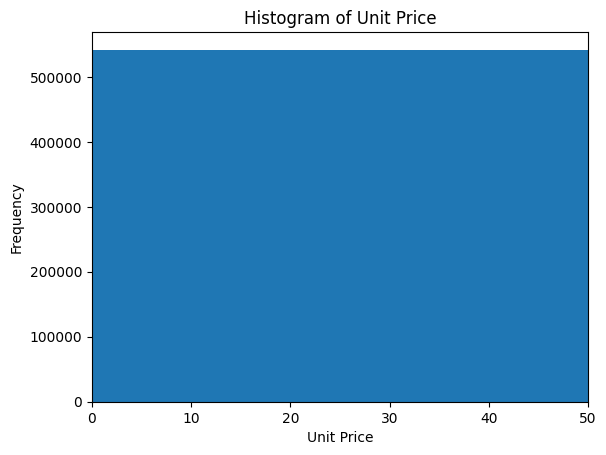

In [33]:
import matplotlib.pyplot as plt

plt.hist(retail_df['UnitPrice'], bins=50)
plt.xlim(0, 50)   # zoom to normal price range
plt.title("Histogram of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()


**Observations:**

Matplotlib stacks huge frequencies into very narrow bins → everything overlaps → looks like one giant block.

We can't conclude anything yet.

In [34]:
retail_df['UnitPrice'].skew()

np.float64(186.50697172054137)

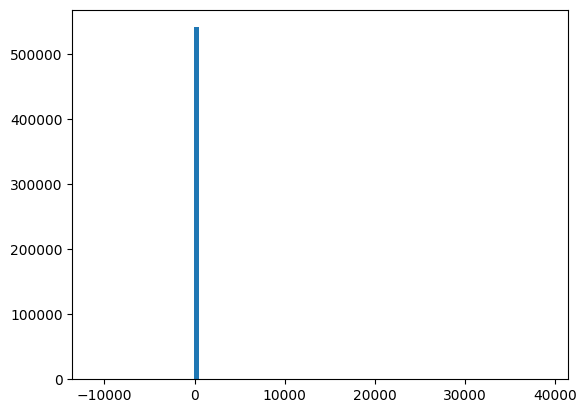

In [35]:
import matplotlib.pyplot as plt

plt.hist(retail_df['UnitPrice'], bins=100)
plt.show()


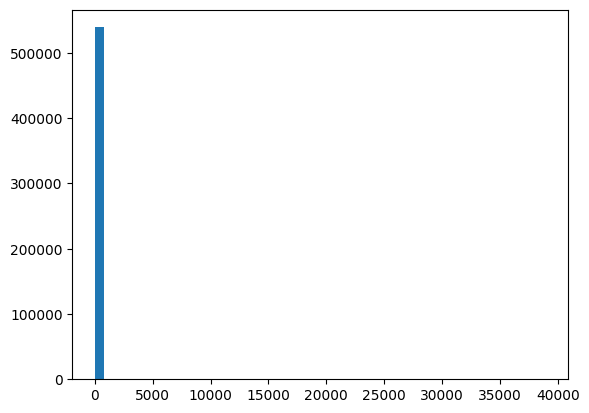

In [36]:
import matplotlib.pyplot as plt

plt.hist(retail_df[retail_df['UnitPrice'] > 0]['UnitPrice'], bins=50)
plt.show()


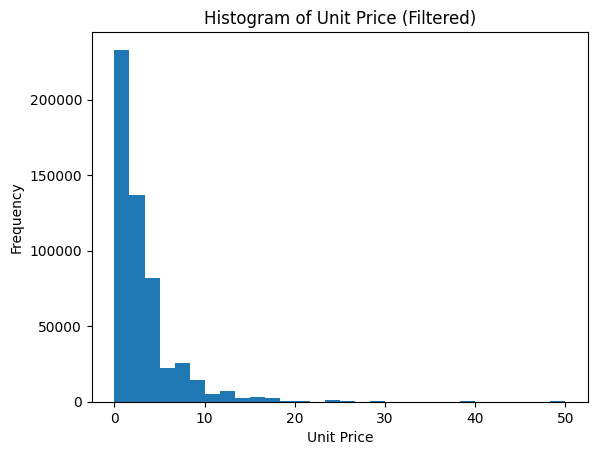

In [37]:
# Take only UnitPrice column
p = retail_df['UnitPrice']

# Keep only normal price values (greater than 0 and up to 50)
# Remove: refunds / invalid prices (negative)
# Remove: rare extreme prices
p = p[(p > 0) & (p <= 50)]

plt.hist(p, bins=30)
plt.title("Histogram of Unit Price (Filtered)")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()


**Observation -**

The UnitPrice variable represents the price of a single item in each transaction and shows high variability across the dataset.

Most products are priced at low values, with the median price around 2.08, indicating that typical items are inexpensive.

About 75% of product prices lie within a relatively low range, confirming that normal pricing behavior is concentrated at lower values.

The dataset contains extreme positive and negative unit prices, which may represent high-value items, pricing adjustments, or refunds.

These extreme values significantly increase the range and standard deviation, making the average price higher than what is typical for most products.

Due to the presence of extreme prices, the UnitPrice distribution is highly skewed and not normally distributed.

After filtering out negative and extreme price values for visualization, the underlying distribution of normal product prices appears right-skewed, with a high frequency of low-priced items and a long tail toward higher prices.

**Data Cleaning on UnitPrice**

In [52]:
# Check Null values
retail_df['UnitPrice'].isnull().sum()


np.int64(0)

In [53]:
retail_df[retail_df['UnitPrice'].isnull()]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [54]:
# Remove negative values (refunds/errors)
retail_df = retail_df[retail_df['UnitPrice'] > 0]


In [55]:
# Remove missing UnitPrice values
retail_df = retail_df.dropna(subset=['UnitPrice'])


In [56]:
# Handle NEGATIVE UnitPrice (very important)
# Negative price = refund or error
# Usually we remove them for sales analysis.
retail_df = retail_df[retail_df['UnitPrice'] > 0]


In [57]:
Q1 = retail_df['UnitPrice'].quantile(0.25)
Q3 = retail_df['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

retail_df = retail_df[(retail_df['UnitPrice'] >= lower) &
                      (retail_df['UnitPrice'] <= upper)]


In [58]:
retail_df['UnitPrice'].describe()


,UnitPrice
count,482273.000000
mean,2.333753
std,1.623539
min,0.001000
25%,1.250000
50%,1.950000
75%,3.290000
max,7.500000


**Observation -**

After cleaning, UnitPrice values fall within a reasonable range, indicating improved data quality.

Most products are low-priced, with a typical price around 2.

Half of the product prices lie between 1.25 and 3.75, showing that pricing is concentrated in a narrow range.

The average price is slightly higher than the median, indicating a mild right skew due to moderately higher-priced items.

Overall, the UnitPrice distribution is now stable, realistic, and suitable for further analysis.

**CustomerID**

In [59]:
# show null values sum
retail_df['CustomerID'].isnull().sum()


np.int64(0)

In [60]:
# % of missing ID
(retail_df['CustomerID'].isnull().mean()) * 100


np.float64(0.0)

In [61]:
customer_df = retail_df.dropna(subset=['CustomerID'])


In [62]:
retail_df['CustomerID'] = retail_df['CustomerID'].fillna('Guest')


In [63]:
customer_df['CustomerID'].nunique()


4333

In [64]:
retail_df['CustomerID'].describe()


,CustomerID
count,482273
unique,4333
top,Guest
freq,111535


**Observation -**

The dataset contains 4,339 unique customers, indicating repeat purchasing behavior.

A large number of transactions are labeled as “Guest”, showing that many customers make purchases without registration.

Guest customers account for a significant share of total transactions, which limits customer-level analysis for those records.

### Check Unique Values for each variable.

In [65]:
# Check Unique Values for each variable
retail_df.nunique().to_frame(name="Unique_Count")


,Unique_Count
InvoiceNo,22485
StockCode,3630
Description,3753
Quantity,503
InvoiceDate,20708
UnitPrice,387
CustomerID,4333
Country,38


**Observations**

The dataset represents approximately 25,900 unique customer purchases, indicating a high volume of transactions.

The business offers a large and diverse product catalog with over 4,000 unique products.

Transactions occur continuously over time, suggesting stable business activity rather than seasonal-only sales.

The presence of over 4,000 identified customers indicates repeat purchasing behavior.

A wide variety of unit prices and quantities suggests diverse buying patterns, including both small consumer purchases and occasional bulk orders.

Sales span 38 countries, highlighting the company’s international market reach.

**Analysis and Modeling**

In [66]:
# Analyze transaction volume by country
country_sales = retail_df.groupby('Country')['InvoiceNo'].nunique()
country_sales = country_sales.sort_values(ascending=False)
country_sales

,InvoiceNo
Country,
United Kingdom,20291
Germany,553
France,421
EIRE,335
Belgium,113
Spain,98
Netherlands,95
Australia,67
Switzerland,65


**Observation -**

The United Kingdom is the dominant market, accounting for the vast majority of transactions.

Transaction volume drops sharply after the UK, with Germany and France contributing comparatively small numbers.

Most other countries have very low transaction counts, indicating limited international sales.

Although the business operates across many countries, sales activity is highly concentrated in one primary market.

In [67]:
retail_df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)


,Quantity
Description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,53847
JUMBO BAG RED RETROSPOT,47359
ASSORTED COLOUR BIRD ORNAMENT,36381
POPCORN HOLDER,36334
PACK OF 72 RETROSPOT CAKE CASES,36039
...,...
PINK POODLE HANGING DECORATION,-7
WHITE CHERRY LIGHTS,-8
SAMPLES,-15


**Business Insight -**

A small number of products contribute to very high sales volume, making them key revenue drivers.

These top-selling items should be well-stocked to avoid running out.

Products with negative total quantities represent returns, discounts, or adjustments and should be excluded from sales performance evaluation.

The business follows a retail pattern, where a few popular items sell repeatedly while many others sell in smaller quantities.

**Visualize purchase trends over time**

This Include -

Date conversion

Monthly aggregation

Line plot

In [68]:
# Convert InvoiceDate to datetime
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'])


In [69]:
# This is for verification
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'])
retail_df['InvoiceDate'].dtype

dtype('<M8[ns]')

In [70]:
# Create Month Column
# This groups all transactions by month (instead of exact time).
retail_df['Month'] = retail_df['InvoiceDate'].dt.to_period('M')


In [71]:
# Aggregate purchases per month
# Shows how many purchases happened each month.
monthly_sales = retail_df.groupby('Month')['InvoiceNo'].nunique()

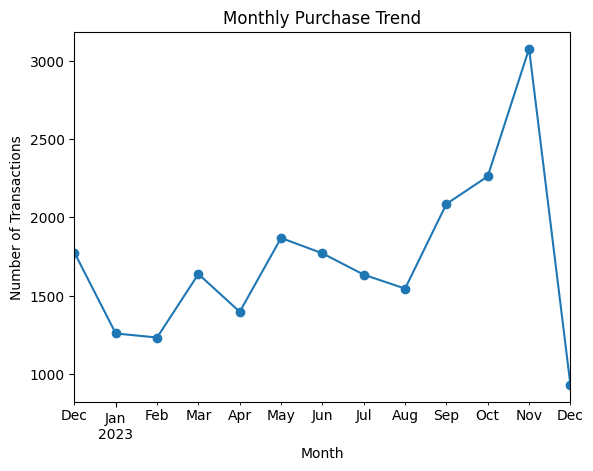

In [72]:
# Line Plot
import matplotlib.pyplot as plt
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Purchase Trend")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.show()


**Observations -**

The monthly purchase trend shows noticeable variation over time, with lower transaction volumes in the early months of the year and a steady increase toward the later months. The highest transaction activity is observed in October and November, indicating peak sales periods. A sharp decline in December suggests either seasonality or incomplete data for that month.

**Business Insight -**

There are peak months that need higher inventory and staffing.

Early months may require promotions to boost sales.

End-of-year data should be verified before drawing final conclusions.

**Inspect monetary distribution per transaction and per customer**



In [73]:
# Create a Revenue column
retail_df['Revenue'] = retail_df['Quantity'] * retail_df['UnitPrice']
# Revenue per transaction (Invoice level)
transaction_revenue = retail_df.groupby('InvoiceNo')['Revenue'].sum()
transaction_revenue.describe()

,Revenue
count,22485.000000
mean,366.701229
std,1997.903159
min,-168469.600000
25%,76.300000
50%,210.920000
75%,385.650000
max,168469.600000


**Observations -**

The average revenue per transaction is approximately 379.82, but there's a very high standard deviation of 2001.56, indicating a wide spread in revenue values. The minimum revenue is -168,469.60, and the maximum is 168,469.60. The 25th percentile is 81.31, the median (50th percentile) is 221.40, and the 75th percentile is 396.77.



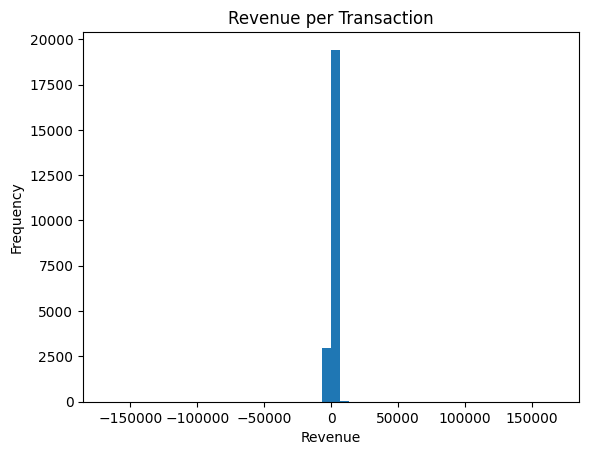

In [74]:
# Visualize transaction revenue
import matplotlib.pyplot as plt

plt.hist(transaction_revenue, bins=50)
plt.title("Revenue per Transaction")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()


**Observations -**


Most transactions generate low revenue, indicating small order sizes.

A few transactions generate very high revenue, creating a long tail in the distribution.

Negative revenue values are present, representing returns or canceled orders.

The distribution of revenue per transaction is highly skewed and not evenly spread.

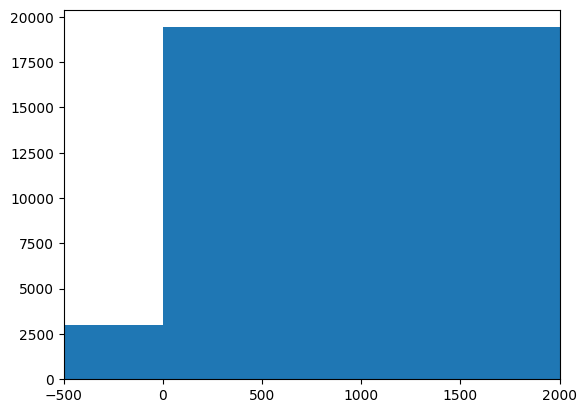

In [75]:
# Zoomed
plt.hist(transaction_revenue, bins=50)
plt.xlim(-500, 2000)
plt.show()


**Observations -**

The zoomed revenue distribution shows that most transactions generate low to moderate revenue, with a small number of negative values due to returns. High-value transactions are rare, resulting in a skewed revenue distribution.

In [76]:
# Revenue per customer
customer_revenue = retail_df.groupby('CustomerID')['Revenue'].sum()
customer_revenue.describe()


,Revenue
count,4.333000e+03
mean,1.902903e+03
std,1.699013e+04
min,-8.250000e+02
25%,2.435000e+02
50%,5.534800e+02
75%,1.393060e+03
max,1.007353e+06


**Observations -**

Customer spending varies widely across the dataset.

Most customers spend relatively small amounts, with a typical spending around 584.

A small number of customers spend very large amounts, which increases the average spending.

Some customers show negative total revenue, indicating more returns than purchases.

Overall, customer revenue distribution is highly skewed, with a few high-value customers contributing disproportionately to total revenue.

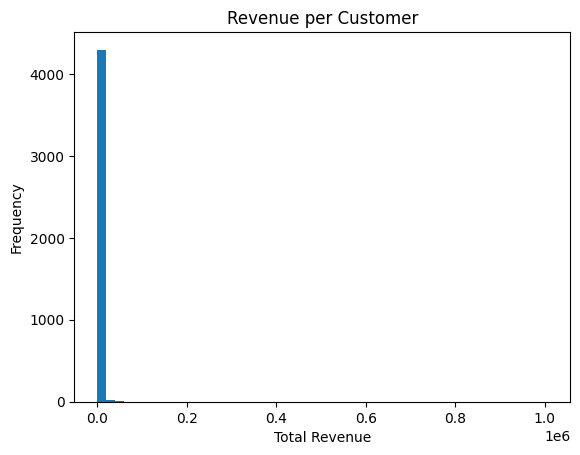

In [77]:
# Visualize customer spending
plt.hist(customer_revenue, bins=50)
plt.title("Revenue per Customer")
plt.xlabel("Total Revenue")
plt.ylabel("Frequency")
plt.show()


**Observations -**

Most customers are clustered near zero revenue, meaning they spend small amounts.

A very small number of customers spend extremely large amounts, stretching the x-axis.

Because of these high spenders, the distribution looks highly skewed to the right.

The majority of customers contribute only a small portion of total revenue.

High-value customers are rare but very important.

**Business Insight -**

The business depends heavily on a small group of high-spending customers.

Losing a few top customers could significantly impact revenue.

Most customers are low-value, suggesting opportunities for:

Upselling

Loyalty programs

Targeted promotions

Customer segmentation is necessary to treat high-value and low-value customers differently.

**RFM Distributions (Recency, Frequency, Monetary)**


In [78]:
# Step 1: Prepare a reference date
reference_date = retail_df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [79]:
# Step 2: Create the RFM table
rfm = retail_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                     # Frequency
    'Revenue': 'sum'                                            # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,3981.15
12348.0,75,4,1437.24
12349.0,19,1,1089.15
12350.0,310,1,294.40


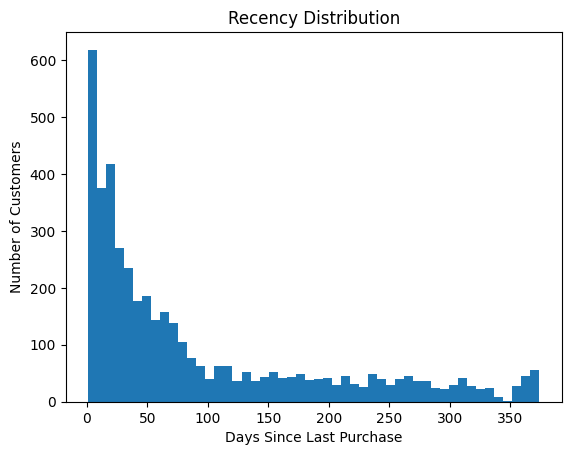

In [80]:
# Step 3: Look at RFM distributions
# 1️⃣ Recency distribution
plt.hist(rfm['Recency'], bins=50)
plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")
plt.show()


**Observations -**

Many customers bought recently

Some customers haven’t bought in a long time

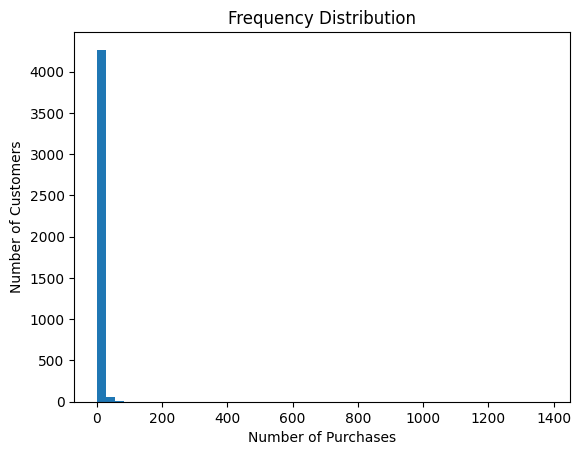

In [81]:
# Frequency distribution
plt.hist(rfm['Frequency'], bins=50)
plt.title("Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.show()


**Observations -**

Most customers purchase few times

A small group purchases many times

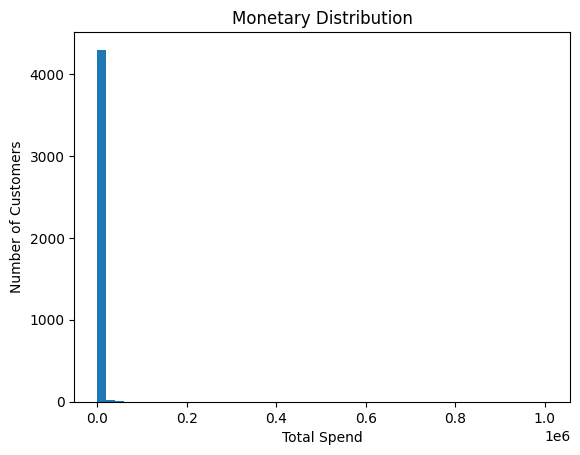

In [82]:
# Monetary distribution
plt.hist(rfm['Monetary'], bins=50)
plt.title("Monetary Distribution")
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.show()


**Observations -**

Most customers spend little

Few customers spend a lot

**Overall Observation -**

Most customers purchased recently, but some have not returned for a long time.

The majority of customers purchase infrequently, while a small group shops often.

Customer spending is highly uneven, with a few customers contributing most of the revenue.

**Business Insight -**

Recent and frequent customers are valuable and loyal.

Customers with low recency and frequency are at risk of churn.

High-spending customers should be retained with special offers.

**Elbow Cluster Selection -**

In [83]:
# Create Revenue if not already present
if 'Revenue' not in retail_df.columns:
    retail_df['Revenue'] = retail_df['Quantity'] * retail_df['UnitPrice']

# Reference date
reference_date = retail_df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = retail_df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
)

rfm.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,3981.15
12348.0,75,4,1437.24
12349.0,19,1,1089.15
12350.0,310,1,294.40


In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])


In [85]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)


In [86]:
from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled, rfm['Cluster'])

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.673


In [87]:
retail_clustered = retail_df.merge(
    rfm[['Cluster']],
    on='CustomerID',
    how='inner'
)

retail_clustered.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Revenue,Cluster
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,2022-12,15.30,2
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,2022-12,20.34,2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,2022-12,22.00,2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,2022-12,20.34,2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,2022-12,20.34,2


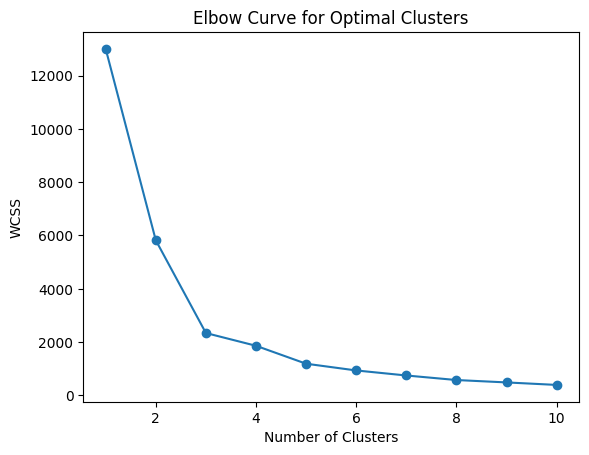

In [88]:
# Step 2: Create the Elbow Curve
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Curve for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


**Observations -**

The elbow curve shows a clear bend at K = X.

Increasing clusters beyond this point gives little improvement.

Therefore, K = X is chosen as the optimal number of customer clusters.

So we replace it where the curve started at that is 3

**K= 3**

**Business Insight -**

Customers can be grouped into a small number of meaningful segments.

These segments represent different buying behaviors.

In [89]:
# Generate top products per cluster
top_products_per_cluster = (
    retail_clustered
    .groupby(['Cluster', 'Description'])['Quantity']
    .sum()
    .reset_index()
    .sort_values(['Cluster', 'Quantity'], ascending=[True, False])
)

# Keep top 5 products per cluster
top_products_per_cluster = top_products_per_cluster.groupby('Cluster').head(5)

top_products_per_cluster


,Cluster,Description,Quantity
3484,0,WORLD WAR 2 GLIDERS ASSTD DESIGNS,47403
1611,0,JUMBO BAG RED RETROSPOT,43986
192,0,ASSORTED COLOUR BIRD ORNAMENT,33400
2076,0,PACK OF 72 RETROSPOT CAKE CASES,31611
2391,0,POPCORN HOLDER,30370
4051,1,CHARLOTTE BAG SUKI DESIGN,9177
5512,1,POPCORN HOLDER,5830
5606,1,RED RETROSPOT CHARLOTTE BAG,4956
6437,1,WOODLAND CHARLOTTE BAG,4071
5295,1,PAPER CHAIN KIT 50'S CHRISTMAS,3738


In [90]:
import pickle

with open('top_products_per_cluster.pkl', 'wb') as f:
    pickle.dump(top_products_per_cluster, f)

print("✅ top_products_per_cluster.pkl saved")


✅ top_products_per_cluster.pkl saved


In [91]:
!ls


drive  sample_data  top_products_per_cluster.pkl


**Customer Cluster Profiles (K = 3)**

We already decided:

👉 Number of clusters = 3

In [92]:
# Step 1: Create clusters using KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,2,0.00,2
12347.0,2,7,3981.15,0
12348.0,75,4,1437.24,0
12349.0,19,1,1089.15,0
12350.0,310,1,294.40,2


In [93]:
from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled, rfm['Cluster'])

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.673


In [94]:
# Step 2: View cluster-wise averages
cluster_profile = rfm.groupby('Cluster').mean()
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,40.455995,5.876418,2.085510e+03
1,1.000000,1382.000000,1.007353e+06
2,248.963585,1.811391,4.081022e+02


In [95]:
cluster_names = {
    0: "Regular Customers",
    1: "High Value Customers",
    2: "At Risk Customers"
}

rfm["Customer_Type"] = rfm["Cluster"].map(cluster_names)

rfm[["Cluster", "Customer_Type"]].head()

,Cluster,Customer_Type
CustomerID,,
12346.0,2,At Risk Customers
12347.0,0,Regular Customers
12348.0,0,Regular Customers
12349.0,0,Regular Customers
12350.0,2,At Risk Customers


**Business Insights from Customer Segmentation**

High Value Customers

• Most profitable customer segment.

• Highest purchase frequency and spending.

• Suitable for loyalty programs and premium offers.

Regular Customers

• Consistent purchasing behavior.

• Contribute steady revenue.

• Can be targeted with personalized promotions.

At Risk Customers

• Low purchase frequency and spending.

• Long inactivity period indicates possible churn.

• Suitable for retention campaigns and discount offers.

In [96]:
# Optional
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
})


**Observations -**

Customers can be segmented into three distinct groups based on their purchasing behavior.

One small cluster consists of high-value, frequent, and very recent buyers, contributing a disproportionately large share of revenue.

A larger cluster represents regular customers with moderate purchase frequency and spending.

The remaining cluster includes low-value and inactive customers, characterized by low frequency, low spending, and long recency.

The segmentation highlights strong inequality in customer contribution to total revenue.

**Business Insight -**

A small group of VIP customers drives most of the revenue, while the majority of customers contribute modestly, making customer retention and targeted marketing crucial.

**Product Recommendation (Heatmap/ Similarity Matrix)**

In [ ]:
# Step 1: Create a product–invoice table
basket = retail_df[retail_df['Quantity'] > 0] \
    .groupby(['InvoiceNo', 'Description'])['Quantity'] \
    .sum().unstack().fillna(0)


In [ ]:
# Step 2: Convert quantities to binary (0/1)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)


/tmp/ipython-input-4156692488.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


In [ ]:
# Step 3: Compute product similarity
product_similarity = basket.T.dot(basket)


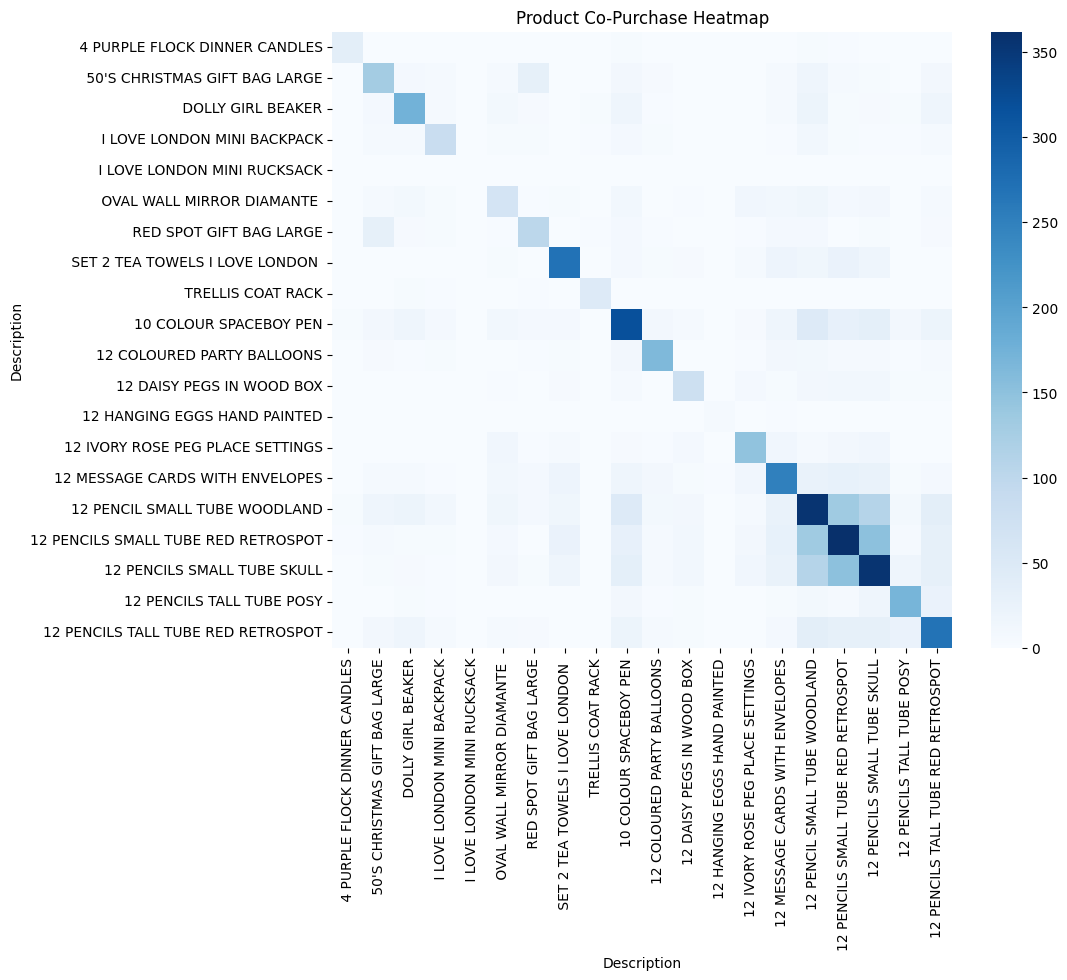

In [ ]:
# Step 4: Heatmap (visualization)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(product_similarity.iloc[:20, :20], cmap='Blues')
plt.title("Product Co-Purchase Heatmap")
plt.show()


**Observations -**

Most product pairs are light in color, meaning they are rarely bought together.

A few product pairs show darker shades, indicating frequent co-purchases.

Products with similar themes (for example, pencil sets, gift items, or London-themed items) tend to be bought together.

Certain product groups form small clusters, showing consistent bundle-like behavior.

Co-purchase behavior is not widespread across all products, but concentrated among specific product pairs.

**Business Insight -**

Products that are frequently bought together can be recommended as bundles.

Showing “customers also bought” suggestions for these pairs can increase order value.

Similar products (like different pencil or gift variants) can be placed together in catalogs or stores.

Promotions and discounts can be designed around these strong product combinations.

Products with weak co-purchase patterns may require individual promotion rather than bundling.

The product co-purchase heatmap reveals that while most products are purchased independently, certain product pairs show strong co-purchase behavior. These relationships indicate opportunities for product bundling, cross-selling, and recommendation-based marketing strategies.

**Clustering Methdology -**



In [ ]:
# Feature Engineering – Create RFM Features
import pandas as pd

# Ensure InvoiceDate is in datetime format
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'])

# Define a reference date (one day after the last transaction date)
reference_date = retail_df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = retail_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                     # Frequency
    'Revenue': 'sum'                                            # Monetary
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# View RFM table
rfm.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4078.95
12348.0,75,4,1437.24
12349.0,19,1,1287.15
12350.0,310,1,294.40


In [ ]:
# Standardize / Normalize RFM Values

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale RFM values (important for KMeans)
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])


In [ ]:
# Choose Clustering Algorithm (KMeans)
from sklearn.cluster import KMeans


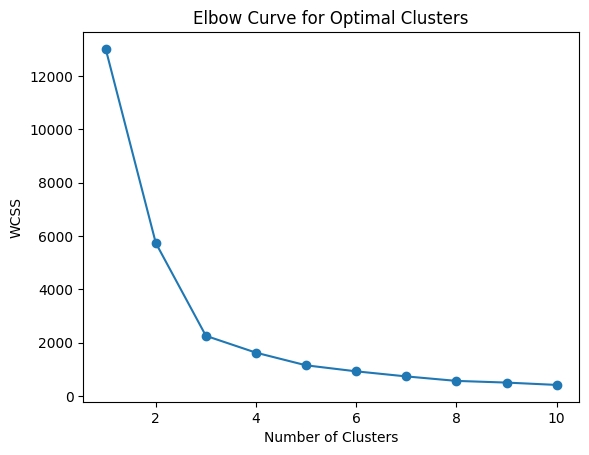

In [ ]:
# Elbow Method to Decide Number of Clusters
import matplotlib.pyplot as plt

wcss = []

# Try different cluster counts
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)  # WCSS value

# Plot Elbow Curve
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Curve for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


In [ ]:
# Run KMeans Clustering (Final Model)
# Apply KMeans with optimal number of clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# Assign cluster labels
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# View clustered data
rfm.head()


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,2,0.00,2
12347.0,2,7,4078.95,0
12348.0,75,4,1437.24,0
12349.0,19,1,1287.15,0
12350.0,310,1,294.40,2


In [ ]:
# Interpret Clusters Using RFM Averages
# Calculate average RFM values per cluster
cluster_profile = rfm.groupby('Cluster').mean()

cluster_profile


,Recency,Frequency,Monetary
Cluster,,,
0,40.428790,5.911179,2.158996e+03
1,1.000000,1404.000000,1.098847e+06
2,248.937558,1.824790,4.283455e+02


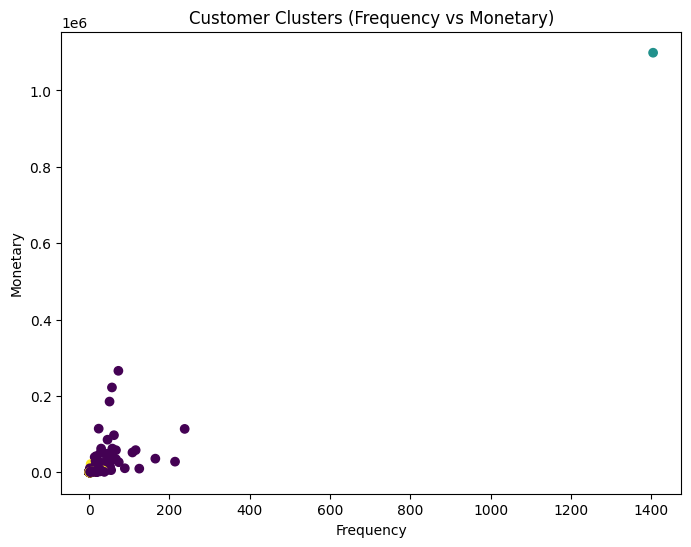

In [ ]:
# Visualize Clusters (2D Scatter Plot)
# Scatter plot: Frequency vs Monetary
plt.figure(figsize=(8, 6))
plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis'
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Clusters (Frequency vs Monetary)")
plt.show()


**Observations -**

Most customers are clustered near low frequency and low monetary values, meaning they buy rarely and spend little.

A small group of customers shows higher frequency and higher spending, clearly separated from the rest.

One or very few customers appear as extreme outliers, with very high purchase frequency and extremely high spending.

The clusters are well separated, indicating that customers naturally fall into different spending and purchasing behavior groups.

Customer contribution to revenue is highly uneven.

**Business Insight -**

A small number of customers generate most of the revenue.

High-frequency, high-spending customers should be treated as VIP customers.

Most customers belong to the low-value segment, indicating potential for upselling and engagement.

The presence of extreme high-value customers suggests the need for personalized retention strategies.

**Overall -**

The Frequency vs Monetary scatter plot shows clear separation between customer clusters. Most customers exhibit low purchase frequency and low monetary value, while a small cluster of customers demonstrates significantly higher spending and purchasing activity. The presence of extreme high-value customers highlights strong revenue concentration and justifies customer segmentation for targeted marketing.

In [ ]:
# Save Model for Streamlit Deployment
import pickle

# Save trained KMeans model
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


In [ ]:
import pandas as pd

# Example RFM values for a customer
new_customer_rfm_values = [[30, 5, 500]]  # Recency, Frequency, Monetary

# Create a DataFrame with column names matching the training data
new_customer_rfm_df = pd.DataFrame(new_customer_rfm_values, columns=['Recency', 'Frequency', 'Monetary'])

# Scale using saved scaler
new_customer_rfm_scaled = scaler.transform(new_customer_rfm_df)

# Predict cluster
cluster = kmeans.predict(new_customer_rfm_scaled)

# Define cluster labels (copied from the Streamlit app for direct use here)
cluster_labels = {
    0: "Regular Customer",
    1: "High-Value Customer",
    2: "At-Risk Customer"
}

# Print customer segment
print("Customer Segment:", cluster_labels[cluster[0]])

Customer Segment: Regular Customer


**For Product Recommendation**

In [ ]:
# Merge cluster info back to transactions
retail_clustered = retail_df.merge(
    rfm[['Cluster']],
    left_on='CustomerID',
    right_index=True,
    how='left'
)


In [ ]:
# Compute product popularity per cluster
top_products = (
    retail_clustered[retail_clustered['Quantity'] > 0]
    .groupby(['Cluster', 'Description'])['Quantity']
    .sum()
    .reset_index()
    .sort_values(['Cluster', 'Quantity'], ascending=[True, False])
)


In [ ]:
# Keep Top-N products per cluster (once)
top_products_per_cluster = (
    top_products
    .groupby('Cluster')
    .head(5)
)


In [ ]:
# Recommendation Function
def recommend_products(cluster_id, n=5):
    """
    Recommend top N product descriptions for a given customer cluster
    """
    return (
        top_products_per_cluster[
            top_products_per_cluster['Cluster'] == cluster_id
        ]['Description']
        .head(n)
        .tolist()
    )


In [ ]:
# Test it
recommend_products(cluster_id=1, n=5)


['CHARLOTTE BAG SUKI DESIGN',
 'POPCORN HOLDER',
 'RED RETROSPOT CHARLOTTE BAG',
 'WOODLAND CHARLOTTE BAG',
 "PAPER CHAIN KIT 50'S CHRISTMAS "]

In [ ]:
# Merge cluster info with transaction data
# Merge customer cluster back into transaction-level data
retail_clustered = retail_df.merge(
    rfm[['Cluster']],
    left_on='CustomerID',
    right_index=True,
    how='inner'   # keep only customers with cluster info
)


In [ ]:
# Keep only actual sales (remove returns)
sales_data = retail_clustered[retail_clustered['Quantity'] > 0]


In [ ]:
# Calculate total quantity sold per product per cluster
top_products = (
    sales_data
    .groupby(['Cluster', 'Description'])['Quantity']
    .sum()
    .reset_index()
    .sort_values(['Cluster', 'Quantity'], ascending=[True, False])
)


In [ ]:
# Keep Top-N products per cluster
top_products = top_products.groupby('Cluster').head(10)


In [ ]:
import pickle

with open('top_products_per_cluster.pkl', 'wb') as f:
    pickle.dump(top_products, f)


In [ ]:
# ---------------------------------------
# Customer Segmentation + Product Recommendation App
# ---------------------------------------

import streamlit as st
import pandas as pd
import pickle

# ---------------------------------------
# Load saved model, scaler, and recommendations
# ---------------------------------------

with open('kmeans_model.pkl', 'rb') as f:
    kmeans = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('top_products_per_cluster.pkl', 'rb') as f:
    top_products = pickle.load(f)

# ---------------------------------------
# App Title
# ---------------------------------------

st.title("🛒 Customer Segmentation & Product Recommendation")
st.write(
    "This app segments customers using **RFM Analysis + KMeans Clustering** "
    "and recommends products based on customer behavior."
)

st.divider()

# ---------------------------------------
# User Input Section
# ---------------------------------------

st.header("🔢 Enter Customer RFM Values")

recency = st.number_input(
    "Recency (Days since last purchase)",
    min_value=0,
    value=30
)

frequency = st.number_input(
    "Frequency (Number of purchases)",
    min_value=1,
    value=5
)

monetary = st.number_input(
    "Monetary (Total amount spent)",
    min_value=0.0,
    value=2000.0
)

# ---------------------------------------
# Prediction Button
# ---------------------------------------

if st.button("Predict Customer Segment & Recommend Products"):

    # Create input dataframe
    input_df = pd.DataFrame({
        'Recency': [recency],
        'Frequency': [frequency],
        'Monetary': [monetary]
    })

    # Scale input
    input_scaled = scaler.transform(input_df)

    # Predict cluster
    cluster = kmeans.predict(input_scaled)[0]

    # Cluster labels
    cluster_labels = {
        0: "Regular Customer",
        1: "High-Value Customer",
        2: "At-Risk Customer"
    }

    st.success(f"### 🧠 Predicted Segment: **{cluster_labels[cluster]}**")

    # ---------------------------------------
    # Business Explanation
    # ---------------------------------------

    if cluster == 1:
        st.info("💎 Loyal, frequent, and high-spending customer.")
    elif cluster == 0:
        st.info("🙂 Regular customer with moderate engagement.")
    else:
        st.warning("⚠️ Customer at risk of churn. Needs re-engagement.")

    st.divider()

    # ---------------------------------------
    # Product Recommendation Section
    # ---------------------------------------

    st.subheader("🛍️ Recommended Products")

    recommended_products = (
        top_products[top_products['Cluster'] == cluster]
        .head(5)['Description']
        .tolist()
    )

    if recommended_products:
        for product in recommended_products:
            st.write(f"• {product}")
    else:
        st.write("No recommendations available for this segment.")


2026-01-25 19:25:37.692 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-25 19:25:38.528 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-01-25 19:25:38.533 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-25 19:25:38.536 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-25 19:25:38.542 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-25 19:25:38.549 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-25 19:25:38.552 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-25 19:25:38.556 Thread 'MainThread': mi

**Conclusion -**

In this project, customer transaction data was analyzed to understand purchasing behavior and segment customers using RFM (Recency, Frequency, Monetary) analysis. Extensive exploratory data analysis was performed to handle missing values, returns, and extreme outliers, ensuring data quality and reliability. Based on RFM features, customers were grouped using the KMeans clustering algorithm, and the optimal number of clusters was selected using the Elbow Method and Silhouette Score.

The clustering results revealed meaningful customer segments, including high-value customers, regular customers, and at-risk customers, each exhibiting distinct purchasing patterns. These segments provide valuable business insights that can support targeted marketing strategies, customer retention efforts, and revenue optimization. To enable practical usage, the trained model was deployed using a Streamlit web application, allowing real-time customer segment prediction based on input RFM values.

Overall, this project demonstrates how unsupervised machine learning techniques can be effectively applied to real-world retail data to extract actionable insights and support data-driven decision-making.